Experiment 6,7

--- Classification Results ---
Accuracy with Original (13 Features): 100.00%
Accuracy with PCA (2 Components): 100.00%
Accuracy with LDA (2 Components): 100.00%


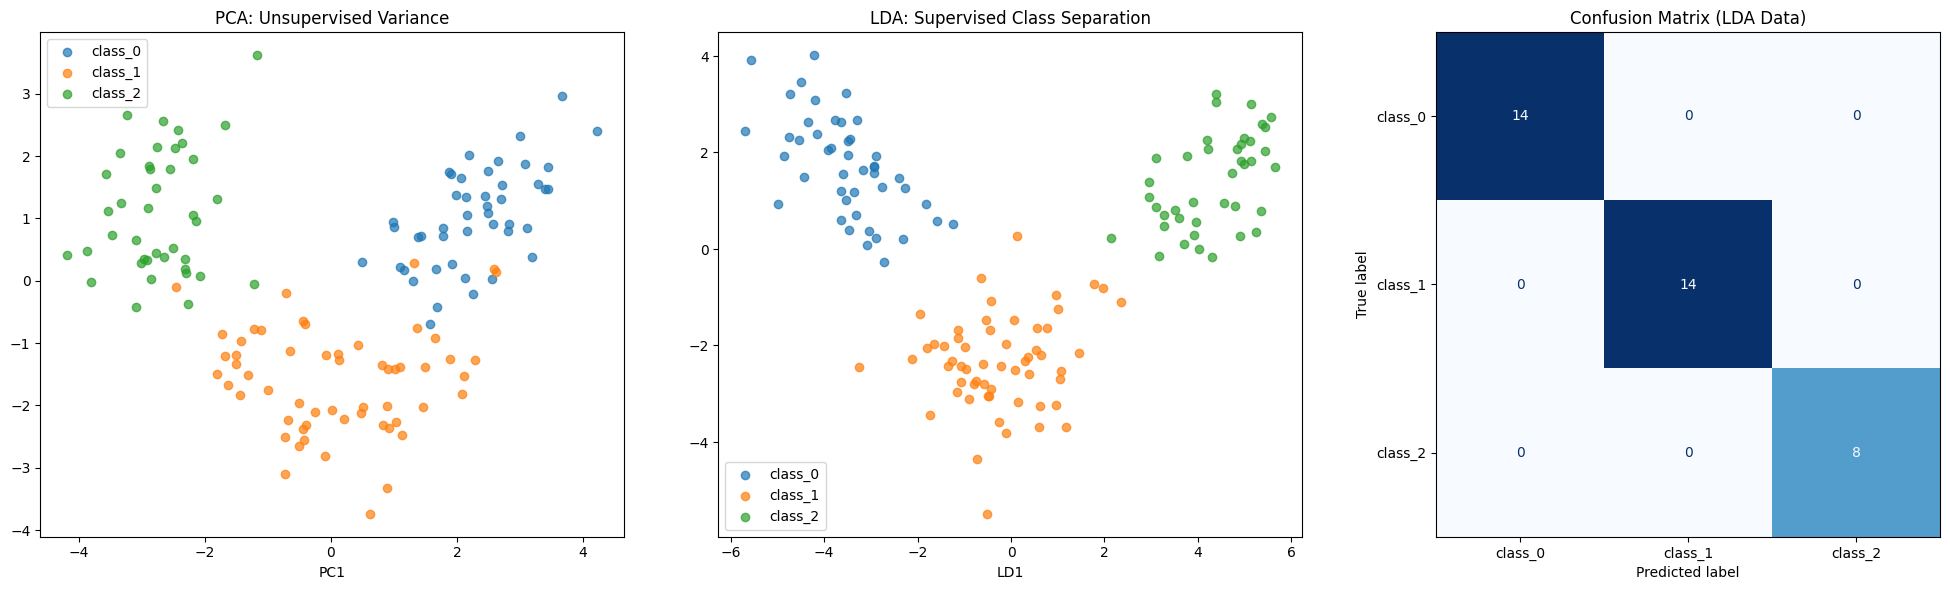

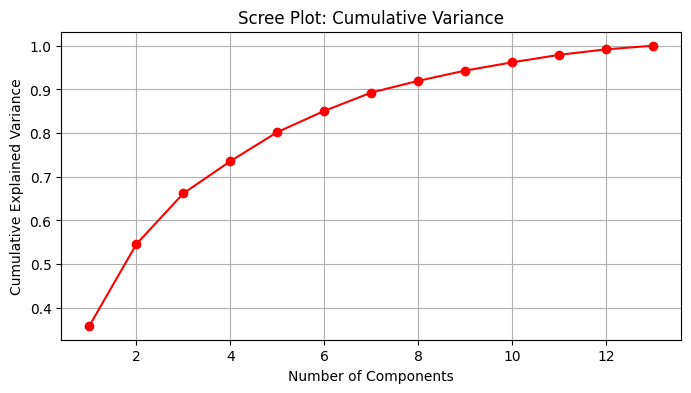

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# 1. LOAD DATA
wine = load_wine()
X, y = wine.data, wine.target
target_names = wine.target_names

# 2. PREPROCESSING
# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize (Crucial for PCA to treat all features equally)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

# 3. DIMENSIONALITY REDUCTION
# PCA (Unsupervised) - Reduce to 2D
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# LDA (Supervised) - Reduce to 2D
lda = LDA(n_components=2) # Initialize LDA
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)

# 4. MODEL TRAINING & EVALUATION
def evaluate_model(train_features, test_features, title):
    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(train_features, y_train)
    preds = clf.predict(test_features)
    acc = accuracy_score(y_test, preds)
    print(f"Accuracy with {title}: {acc*100:.2f}%")
    return clf, preds

print("--- Classification Results ---")
model_orig, _ = evaluate_model(X_train_std, X_test_std, "Original (13 Features)")
model_pca, _  = evaluate_model(X_train_pca, X_test_pca, "PCA (2 Components)")
model_lda, preds_lda = evaluate_model(X_train_lda, X_test_lda, "LDA (2 Components)")

# 5. VISUALIZATION
fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# PCA Plot
for i, name in enumerate(target_names):
    ax[0].scatter(X_train_pca[y_train == i, 0], X_train_pca[y_train == i, 1], label=name, alpha=0.7)
ax[0].set_title("PCA: Unsupervised Variance")
ax[0].set_xlabel("PC1")
ax[0].legend()

# LDA Plot
for i, name in enumerate(target_names):
    ax[1].scatter(X_train_lda[y_train == i, 0], X_train_lda[y_train == i, 1], label=name, alpha=0.7)
ax[1].set_title("LDA: Supervised Class Separation")
ax[1].set_xlabel("LD1")
ax[1].legend()

# Confusion Matrix for the LDA Model
cm = confusion_matrix(y_test, preds_lda)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax[2], cmap='Blues', colorbar=False)
ax[2].set_title("Confusion Matrix (LDA Data)")

plt.tight_layout()
plt.show()

# 6. SCREE PLOT (Optimal Components for PCA)
pca_full = PCA().fit(X_train_std)
plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(pca_full.explained_variance_ratio_) + 1),
         np.cumsum(pca_full.explained_variance_ratio_), 'ro-')
plt.title("Scree Plot: Cumulative Variance")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

Experiment 8


In [12]:
# ==========================================
# STEP 1: IMPORT LIBRARIES
# ==========================================
import pandas as pd
import numpy as np

from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


# ==========================================
# STEP 2: LOAD CSV DATASET
# ==========================================
data = pd.read_csv("F1(Drivers)-Dataset-E0124099.csv")

print("Dataset:\n", data.head())


# ==========================================
# STEP 3: ENCODE CATEGORICAL DATA (IMPORTANT)
# ==========================================
encoders = {}

# Impute NaNs with 0.0 before encoding to ensure all numerical categories
# (like 0.0) are learned by LabelEncoder, especially for columns
# that might have had NaNs in the original data (e.g., 'Championship Years').
data = data.fillna(0.0)

for column in data.columns:
    # Convert ALL columns to string type before encoding
    # This ensures LabelEncoder treats all values as categorical strings,
    # preventing issues with mixed types or unseen numerical values like 0.0
    data[column] = data[column].astype(str)
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    encoders[column] = le   # Save encoder

print("\nEncoded Data:\n", data.head())


# ==========================================
# STEP 4: SPLIT FEATURES AND TARGET
# ==========================================
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

print("\nFeatures:\n", X.head())
print("\nTarget:\n", y.head())


# ==========================================
# STEP 5: TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# ==========================================
# STEP 6: TRAIN NAÏVE BAYES MODEL
# ==========================================
# To fix IndexError when CategoricalNB's `categories` argument is not available (older sklearn versions)
# This ensures that X_train contains all possible integer categories that X_test might contain
# by temporarily extending X_train with dummy entries for categories not seen in the training split.

X_train_extended = X_train.copy()
y_train_extended = y_train.copy()

for col_idx, col_name in enumerate(X.columns):
    # Get all possible encoded integer categories for this feature from the full dataset's LabelEncoder
    all_possible_categories = set(range(len(encoders[col_name].classes_)))

    # Get categories present in the current X_train
    categories_in_current_train = set(X_train[col_name].unique())

    # Identify categories that are possible but not present in X_train
    missing_categories = all_possible_categories - categories_in_current_train

    for missing_cat_val in missing_categories:
        # Create a dummy row for X_train_extended
        # Fill with a default value (e.g., 0) for other columns
        dummy_row_x = pd.Series(0, index=X_train.columns)
        dummy_row_x[col_name] = missing_cat_val
        X_train_extended = pd.concat([X_train_extended, pd.DataFrame([dummy_row_x])], ignore_index=True)

        # Add a corresponding dummy target value (e.g., the first class, 0)
        y_train_extended = pd.concat([y_train_extended, pd.Series([0])], ignore_index=True)

model = CategoricalNB()
model.fit(X_train_extended, y_train_extended)

print("\nModel trained successfully!")


# ==========================================
# STEP 7: MAKE PREDICTIONS
# ==========================================
y_pred = model.predict(X_test)

print("\nPredictions:\n", y_pred)


# ==========================================
# STEP 8: EVALUATE MODEL
# ==========================================
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ==========================================
# STEP 9: PREDICT NEW SAMPLE (CORRECT WAY)
# ==========================================
# New sample reflecting the F1(Drivers) dataset columns
new_sample = {
    "Driver": "Carlo Abate",  # Example string driver name (must be in original dataset for LabelEncoder)
    "Nationality": "United Kingdom",
    "Seasons": "[2023]", # Example season as a string
    "Championships": 0.0,
    "Race_Entries": 5.0,
    "Race_Starts": 5.0,
    "Pole_Positions": 0.0,
    "Race_Wins": 0.0,
    "Podiums": 0.0,
    "Fastest_Laps": 0.0,
    "Points": 0.0,
    "Active": True,
    "Championship Years": 0.0,
    "Decade": 2020,
    "Pole_Rate": 0.0,
    "Start_Rate": 1.0,
    "Win_Rate": 0.0,
    "Podium_Rate": 0.0,
    "FastLap_Rate": 0.0,
    "Points_Per_Entry": 0.0,
    "Years_Active": 1
}

# Convert to DataFrame
new_df = pd.DataFrame([new_sample])

# Ensure new_df columns are also string type before encoding
for column in new_df.columns:
    new_df[column] = new_df[column].astype(str) # Convert new_sample values to string before transforming

# Encode using SAME encoders
for column in new_df.columns:
    # Only transform columns for which an encoder exists (i.e., categorical columns)
    if column in encoders:
        new_df[column] = encoders[column].transform(new_df[column])

# Predict
prediction = model.predict(new_df)

# Decode output
predicted_label = encoders[data.columns[-1]].inverse_transform(prediction)

print("\nNew Sample Prediction:", predicted_label[0])

Dataset:
               Driver     Nationality                         Seasons  \
0        Carlo Abate           Italy                    [1962, 1963]   
1   George Abecassis  United Kingdom                    [1951, 1952]   
2      Kenny Acheson  United Kingdom                    [1983, 1985]   
3  Andrea de Adamich           Italy  [1968, 1970, 1971, 1972, 1973]   
4     Philippe Adams         Belgium                          [1994]   

   Championships  Race_Entries  Race_Starts  Pole_Positions  Race_Wins  \
0            0.0           3.0          0.0             0.0        0.0   
1            0.0           2.0          2.0             0.0        0.0   
2            0.0          10.0          3.0             0.0        0.0   
3            0.0          36.0         30.0             0.0        0.0   
4            0.0           2.0          2.0             0.0        0.0   

   Podiums  Fastest_Laps  ...  Championship Years  Decade Pole_Rate  \
0      0.0           0.0  ...            